<a href="https://colab.research.google.com/github/kunal-sharma-2803/AI-ML/blob/main/sample_project1/sklearn_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Getting data ready
### Three main things we have to do
1. split the data into features and labels (usually X and Y)
2. Filling (also called imputing) or disregarding missing values
3. converting non-numerical values to numerical values (also called feature encoding)

In [2]:
heart_disease = pd.read_csv("heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# this is features
X = heart_disease.drop("target", axis=1)
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [4]:
# this is labels
Y = heart_disease.target
Y.head()

,target
0,1
1,1
2,1
3,1
4,1


In [5]:
# split the data into training and test sets
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

In [6]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((242, 13), (61, 13), (242,), (61,))

### Clean Data -> Transform Data -> Reduce Data

### 1.1 Make sure it is all numerical

In [7]:
car_sales = pd.read_csv("car-sales-extended.csv")
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [8]:
car_sales.dtypes

,0
Make,object
Colour,object
Odometer (KM),int64
Doors,int64
Price,int64


In [9]:
# Split the data
X = car_sales.drop("Price",axis=1)
Y = car_sales.Price

# split into training and test
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2)

In [10]:
# from sklearn.ensemble import RandomForestRegressor

# model = RandomForestRegressor()
# model.fit(X_train,Y_train)
# model.score(X_test,Y_test)

# this will give an error

### ML models cant deal with strings, it only knows numbers

In [11]:
# turn categories into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"] # doors are either 2,3,4 so this can also be treated as categories
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",one_hot,categorical_features)],remainder="passthrough")

transformed_X = transformer.fit_transform(X)
transformed_X

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]])

In [12]:
pd.DataFrame(transformed_X)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


In [13]:
X.head()

,Make,Colour,Odometer (KM),Doors
0,Honda,White,35431,4
1,BMW,Blue,192714,5
2,Honda,White,84714,4
3,Toyota,White,154365,4
4,Nissan,Blue,181577,3


<img src="one_hot_encoding.jpg">

In [14]:
# another way
dummeies = pd.get_dummies(car_sales[["Make","Colour","Doors"]])
dummeies

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4,False,True,False,False,False,False,False,False,True
1,5,True,False,False,False,False,True,False,False,False
2,4,False,True,False,False,False,False,False,False,True
3,4,False,False,False,True,False,False,False,False,True
4,3,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,4,False,False,False,True,True,False,False,False,False
996,3,False,False,True,False,False,False,False,False,True
997,4,False,False,True,False,False,True,False,False,False
998,4,False,True,False,False,False,False,False,False,True


In [15]:
np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor

Y = car_sales.Price

X_train,X_test,Y_train,Y_test = train_test_split(transformed_X,Y,test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train,Y_train)

model.score(X_test,Y_test)

0.3235867221569877

### 1.2 Dealing with missing values
1. Fill them with some value (aka imputation)
2. Remove the samples with missing data altogether

In [16]:
car_sales_missing = pd.read_csv("car-sales-extended-missing-data.csv")
car_sales_missing.tail()

,Make,Colour,Odometer (KM),Doors,Price
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0
999,Toyota,Blue,248360.0,4.0,12732.0


In [17]:
car_sales_missing.isna().sum()

,0
Make,49
Colour,50
Odometer (KM),50
Doors,50
Price,50


In [18]:
## convert data to numbers
X = car_sales_missing.drop("Price",axis=1)
Y = car_sales_missing.Price

#### we have to fix the missing data first
### option 1 :- using pandas


In [19]:
# Fill the "Make" column
car_sales_missing.fillna({"Make" : "missing"},inplace=True)
# Fill the "Colour" column
car_sales_missing.fillna({"Colour" : "missing" },inplace=True)
# Fill the "Odometer" column
car_sales_missing.fillna({ "Odometer (KM)" : car_sales_missing["Odometer (KM)"].mean() },inplace=True)
# Fill the "Doors" column
car_sales_missing.fillna({"Doors" : 4},inplace=True)

In [20]:
car_sales_missing.isna().sum()

,0
Make,0
Colour,0
Odometer (KM),0
Doors,0
Price,50


In [21]:
# as we are predicting the price itself there is no point filling it so we remove it
car_sales_missing.dropna(inplace=True)

In [22]:
car_sales_missing.isna().sum()

,0
Make,0
Colour,0
Odometer (KM),0
Doors,0
Price,0


In [23]:
## convert data to numbers
X = car_sales_missing.drop("Price",axis=1)
Y = car_sales_missing.Price

In [24]:
# turn categories into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"] # doors are either 2,3,4 so this can also be treated as categories
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",one_hot,categorical_features)],remainder="passthrough")

transformed_X = transformer.fit_transform(X)
transformed_X.toarray()

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]])

### Option 2 :- using SciKit-learn

In [25]:
car_sales_missing = pd.read_csv("car-sales-extended-missing-data.csv")
car_sales_missing.tail()

,Make,Colour,Odometer (KM),Doors,Price
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0
999,Toyota,Blue,248360.0,4.0,12732.0


In [26]:
car_sales_missing.isna().sum()

,0
Make,49
Colour,50
Odometer (KM),50
Doors,50
Price,50


In [27]:
# drop from price first
car_sales_missing.dropna(subset=["Price"],inplace=True)
car_sales_missing.isna().sum()

,0
Make,47
Colour,46
Odometer (KM),48
Doors,47
Price,0


In [28]:
X = car_sales_missing.drop("Price",axis=1)
Y = car_sales_missing.Price

In [29]:
# Fill missing values
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

categorical_imputer = SimpleImputer(strategy="constant", fill_value="missing")
door_imputer = SimpleImputer(strategy="constant",fill_value=4)
num_imputer = SimpleImputer(strategy="mean")

categorical_features = ["Make","Colour"]
door_features = ["Doors"]
num_featuers = ["Odometer (KM)"]

imputer = ColumnTransformer([("categorical_imputer",categorical_imputer,categorical_features),
                             ("door_imputer",door_imputer,door_features),
                             ("num_imputer",num_imputer,num_featuers)]) # name,imputer,columns

filled_X = imputer.fit_transform(X)

In [30]:
filled_X

array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], dtype=object)

In [31]:
car_sales_filled = pd.DataFrame(filled_X,columns=["Make","Colour","Doors","Odometer (KM)"])
car_sales_filled.head()

,Make,Colour,Doors,Odometer (KM)
0,Honda,White,4.0,35431.0
1,BMW,Blue,5.0,192714.0
2,Honda,White,4.0,84714.0
3,Toyota,White,4.0,154365.0
4,Nissan,Blue,3.0,181577.0


In [32]:
car_sales_filled.isna().sum()

,0
Make,0
Colour,0
Doors,0
Odometer (KM),0


In [33]:
X = car_sales_filled

In [34]:
# turn categories into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"] # doors are either 2,3,4 so this can also be treated as categories
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",one_hot,categorical_features)],remainder="passthrough")

transformed_X = transformer.fit_transform(X)
transformed_X.toarray()

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]])

In [35]:
# fit a model
np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(transformed_X,Y,test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train,Y_train)
model.score(X_test,Y_test)

0.21990196728583944

#### This performs worse because
1. it has less samples
2. the data is filled and not real

# 2. Choosing the right estimator/algorithm for our problem

#### SciKit-learn uses estimator as another term for out ML model or algorithm

- Classification :- predicting weather a sample is one thing or another
- Regression :- predicting a number

google :- sklearn ml map

### 2.1 Picking a ML model for a regression Problem

In [36]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [37]:
diabetes_df = pd.DataFrame(diabetes["data"],columns=diabetes["feature_names"])
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [38]:
diabetes_df["target"] = pd.Series(diabetes["target"])
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [39]:
# how many samples
len(diabetes_df)

442

In [40]:
# lets try ridge regeression, idea from ml map
from sklearn.linear_model import Ridge

# so results can be reproduced
np.random.seed(42)

# get the data
X = diabetes_df.drop("target",axis=1)
Y = diabetes_df.target

# split the data
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

# fit to model :- asking model to find patterns
model = Ridge()
model.fit(X_train,Y_train)

# test our model
model.score(X_test,Y_test)

0.41915292635986545

this is not a good score so Ridge might not be working so go to the map again to check if something else can be done

In [41]:
# try random forest from ensemble
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

model = RandomForestRegressor()
model.fit(X_train,Y_train)

model.score(X_test,Y_test)

0.4428225673999313

### 2.2 Picking a ML model for a classification Problem

In [42]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [43]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = heart_disease.drop("target",axis = 1)
Y = heart_disease.target

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size=0.2)

model = LinearSVC()
model.fit(X_train,Y_train)

model.score(X_test,Y_test)

0.7695473251028807

In [44]:
# this is low so go to another model

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_disease.drop("target",axis = 1)
Y = heart_disease.target

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size=0.2)

model = RandomForestClassifier()
model.fit(X_train,Y_train)

model.score(X_test,Y_test)

0.831275720164609

#### Hint :-
1. if you have structured data use ensemble methods
2. if you have unstructured data then use deep learning or transfer learning

## 3. Fit the model/algo on our data to make predictions

### 3.1 Fitting the model to our data

In [45]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [46]:
Y.head()

,target
0,1
1,1
2,1
3,1
4,1


Fit means the model looks at "X" and tries to find patterns which lead to "Y"  
When we pass the testing data, these patterns are used to find patterns

### 3.2 Make predictions using a ml model

#### use a trained model to make predictions

There are 2 main ways
1. `predict`
2. `predict_proba`

In [47]:
# model.predict(np.array([1,2,8,6]))

# this will give error

In [48]:
# the above doesnt work because, the format of training data and test data has to be the same

model.predict(X_test)

array([0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1])

In [49]:
np.array(Y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1])

In [50]:
# comparing the prediction to the truths
Y_preds = model.predict(X_test)
np.mean(Y_preds == Y_test)

np.float64(0.831275720164609)

In [51]:
model.score(X_test,Y_test)
# this does the smae thing as above

0.831275720164609

In [52]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,Y_preds)
# this also does the same thing

0.831275720164609

In [53]:
# Making predictions using predict_proba

# predict_proba() returns probabilities of a classification label
model.predict_proba(X_test[:5])
# returns the probability of a label being true
# [prob. of 0, prob. of 1]
# if target column had [0,1,2,.....,n] as values then the prob would also have [0,1,2....n]

array([[0.93, 0.07],
       [0.42, 0.58],
       [0.33, 0.67],
       [0.88, 0.12],
       [0.23, 0.77]])

In [54]:
model.predict(X_test[:5])

array([0, 1, 1, 0, 1])

## 4. Evaluating a ML model
1. Estimator `score` method
2. the `scoring` parameter
3. problem specific metric functions

### 4.1 Evaluating a model with `score`

In [55]:
model.score(X_test,Y_test)
# the score method for each type of model has a different metric, check via shift+tab that what exactly is the score doing

0.831275720164609

### 4.2 Evaluating using `scoring` parameter

In [56]:
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_disease.drop("target",axis = 1)
Y = heart_disease.target

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size=0.2)

model = RandomForestClassifier()
model.fit(X_train,Y_train)


RandomForestClassifier()

In [57]:
model.score(X_test,Y_test)

0.831275720164609

In [58]:
np.random.seed(42)
cross_val_score(model,X,Y)
# this means cross validation score

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

<img src="cross-validation.jpg">

In [59]:
np.random.seed(42)
cross_val_score(model,X,Y,cv=10)
# here cv means how many fold cross-validation do we want, 5 is just the default

array([0.80645161, 0.80645161, 0.87096774, 0.9       , 0.9       ,
       0.83333333, 0.73333333, 0.83333333, 0.73333333, 0.76666667])

In [60]:
model_single_score = model.score(X_test,Y_test)
model_cross_val_score = np.mean(cross_val_score(model,X,Y))

model_single_score, model_cross_val_score

(0.831275720164609, np.float64(0.8116939890710382))

In [61]:
# cross_val should be preffered over score
np.random.seed(42)
cross_val_score(model,X,Y,scoring=None)
# this none (by default) means cross_val will use the default evaluation metric of the mdoel, which is given by .score method

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

### 4.2.1 Classification model evaluations metrics
1. accuracy
2. area under ROC curve
3. confusion matrix
4. classification report

`Accuracy`

In [62]:
np.random.seed(42)
cross_val_score = cross_val_score(model,X,Y)

In [63]:
np.mean(cross_val_score)

np.float64(0.8248087431693989)

`ROC Curve`

##### ROC :- reciever operating characteristics curve
##### AUC :- area under curve

ROC curves are a comparison of a model's true +ve rate (tpr) versus a model false +ve rate (fpr)  
* True +ve :- model predicts 1 when truth is 1  
* False +ve :- model predicts 1 when truth is 0  
* True -ve :- model predicts 0 when truth is 0  
* False -ve :- model predicts 0 when truth is 1  


In [64]:
Y_prob = model.predict_proba(X_test)

In [65]:
Y_prob[:10]

array([[0.93, 0.07],
       [0.42, 0.58],
       [0.33, 0.67],
       [0.88, 0.12],
       [0.23, 0.77],
       [0.23, 0.77],
       [0.6 , 0.4 ],
       [0.96, 0.04],
       [0.91, 0.09],
       [0.41, 0.59]])

In [66]:
Y_prob_positive = Y_prob[:, 1]
Y_prob_positive[:10]

array([0.07, 0.58, 0.67, 0.12, 0.77, 0.77, 0.4 , 0.04, 0.09, 0.59])

In [67]:
# calculate fpr,tpr,thresholds
from sklearn.metrics import roc_curve
fpr,tpr,thresholds = roc_curve(Y_test,Y_prob_positive)

In [68]:
# check the false +ve rates
fpr

array([0.        , 0.        , 0.        , 0.00917431, 0.00917431,
       0.00917431, 0.00917431, 0.00917431, 0.00917431, 0.00917431,
       0.00917431, 0.01834862, 0.01834862, 0.01834862, 0.01834862,
       0.02752294, 0.03669725, 0.03669725, 0.04587156, 0.04587156,
       0.05504587, 0.0733945 , 0.08256881, 0.10091743, 0.10091743,
       0.10091743, 0.10091743, 0.11009174, 0.11009174, 0.11009174,
       0.12844037, 0.12844037, 0.13761468, 0.18348624, 0.19266055,
       0.20183486, 0.20183486, 0.21100917, 0.22018349, 0.22018349,
       0.24770642, 0.26605505, 0.28440367, 0.30275229, 0.32110092,
       0.33944954, 0.35779817, 0.36697248, 0.3853211 , 0.3853211 ,
       0.40366972, 0.42201835, 0.4587156 , 0.46788991, 0.48623853,
       0.50458716, 0.53211009, 0.55045872, 0.55963303, 0.57798165,
       0.59633028, 0.63302752, 0.68807339, 0.69724771, 0.71559633,
       0.7706422 , 0.80733945, 0.83486239, 0.88073394, 0.93577982,
       0.96330275, 0.98165138, 1.        ])

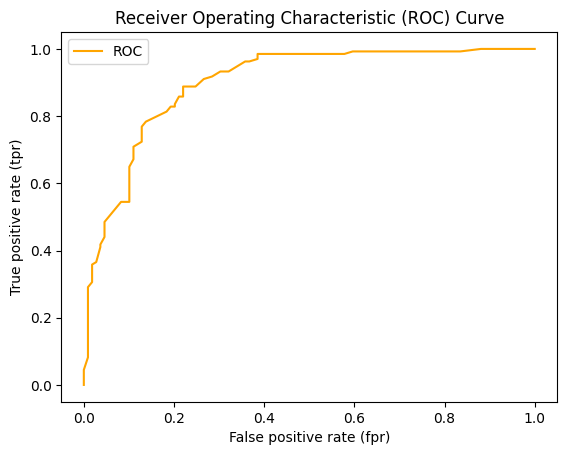

In [69]:
# create a function for processing ROC curves
import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):

    # Plot ROC Curve
    plt.plot(fpr,tpr,color="orange",label="ROC")

    # Plot the line with no predictive power (baseline)
    #plt.plot([0,1], [0,1], color="darkblue", linestyle="--", label="Guessing")

    # Customise the plot
    plt.xlabel("False positive rate (fpr)")
    plt.ylabel("True positive rate (tpr)")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

plot_roc_curve(fpr,tpr)

In [70]:
from sklearn.metrics import roc_auc_score

roc_auc_score(Y_test,Y_prob_positive)

np.float64(0.899561823907983)

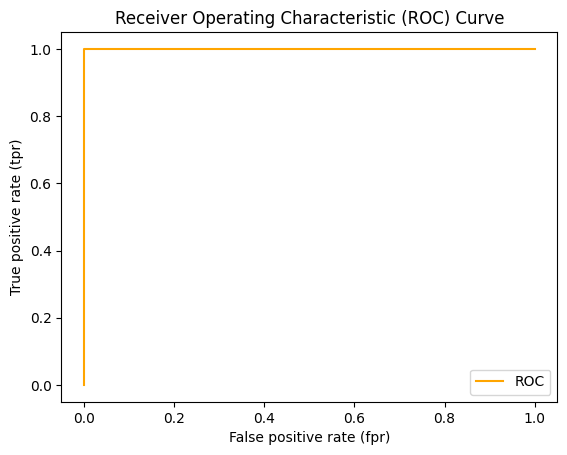

In [71]:
# Plot perfect roc curve

fpr,tpr,threshold = roc_curve(Y_test,Y_test)
plot_roc_curve(fpr,tpr)

In [72]:
roc_auc_score(Y_test,Y_test)

np.float64(1.0)

### Confusion Matrix

A confusion matrix is a quick way to compare the labels a model predicts and the actual labels it was supossed to predict  
In essence giving you an idea where the model is getting confused  

In [73]:
from sklearn.metrics import confusion_matrix

Y_preds = model.predict(X_test)

confusion_matrix(Y_test,Y_preds)

array([[ 80,  29],
       [ 12, 122]])

In [74]:
# Visualise confusion matrix with pd.crosstab()

pd.crosstab(Y_test,Y_preds,rownames=["Actual Labels"],colnames=["Predictred Lables"])

Predictred Lables,0,1
Actual Labels,,
0,80,29
1,12,122


In [75]:
len(Y_preds)

243

In [76]:
80+12+29+122

243

In [77]:
# Bonus :- installing a module to environment from the notebook

# import sys
# !conda install --yes --prefix {sys.prefix} seaborn

<Axes: >

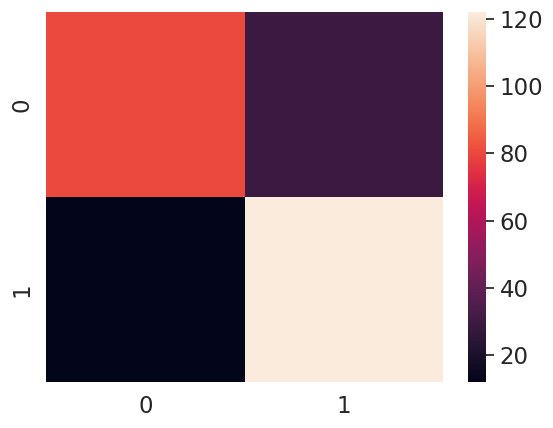

In [78]:
# Make our confusion matrix more visual with seaborn heatmap

import seaborn as sns

sns.set(font_scale=1.5)

conf_mat = confusion_matrix(Y_test,Y_preds)

sns.heatmap(conf_mat)

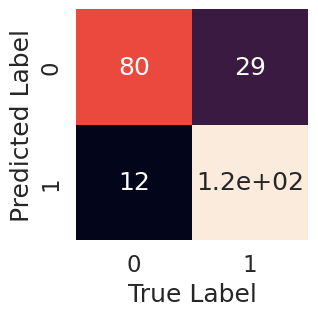

In [79]:
def plot_conf_map(conf_mat):

    fig,ax = plt.subplots(figsize=(3,3))
    ax = sns.heatmap(conf_mat,annot=True,cbar=False)

    plt.xlabel("True Label")
    plt.ylabel("Predicted Label")

plot_conf_map(conf_mat)

In [80]:
### Clasification report :-
#Collecteion of different evaluation metrics

In [81]:
from sklearn.metrics import classification_report

print(classification_report(Y_test,Y_preds))

              precision    recall  f1-score   support

           0       0.87      0.73      0.80       109
           1       0.81      0.91      0.86       134

    accuracy                           0.83       243
   macro avg       0.84      0.82      0.83       243
weighted avg       0.84      0.83      0.83       243



In [82]:
# Precision - Indicates the proportion of positive identifications (model predicted class 1) which were actually correct. A model which produces no false positives has a precision of 1.0.
# Recall - Indicates the proportion of actual positives which were correctly classified. A model which produces no false negatives has a recall of 1.0.
# F1 score - A combination of precision and recall. A perfect model achieves an F1 score of 1.0.
# Support - The number of samples each metric was calculated on.
# Accuracy - The accuracy of the model in decimal form. Perfect accuracy is equal to 1.0, in other words, getting the prediction right 100% of the time.
# Macro avg - Short for macro average, the average precision, recall and F1 score between classes. Macro avg doesn't take class imbalance into effect. So if you do have class imbalances (more examples of one class than another), you should pay attention to this.
# Weighted avg - Short for weighted average, the weighted average precision, recall and F1 score between classes. Weighted means each metric is calculated with respect to how many samples there are in each class. This metric will favour the majority class (e.g. it will give a high value when one class out performs another due to having more samples).

In [83]:
pd.DataFrame(classification_report(Y_test,Y_preds,output_dict=True))
# another way to visualise

,0,1,accuracy,macro avg,weighted avg
precision,0.869565,0.807947,0.831276,0.838756,0.835586
recall,0.733945,0.910448,0.831276,0.822196,0.831276
f1-score,0.796020,0.856140,0.831276,0.826080,0.829173
support,109.000000,134.000000,0.831276,243.000000,243.000000


In [84]:
# where classification report becomes valuable

disease_true = np.zeros(10000)
disease_true[0] = 1

disease_preds = np.zeros(10000) # lets say our model predicted every one as zero

pd.DataFrame(classification_report(disease_true,disease_preds,output_dict=True))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,0.0,1.0,accuracy,macro avg,weighted avg
precision,0.99990,0.0,0.9999,0.499950,0.99980
recall,1.00000,0.0,0.9999,0.500000,0.99990
f1-score,0.99995,0.0,0.9999,0.499975,0.99985
support,9999.00000,1.0,0.9999,10000.000000,10000.00000


In [85]:
# 4.2.2 Regression model evaluation metrics

In [86]:
# R^2 (pronounced r-squared) or coefficient of determination - Compares your models predictions to the mean of the targets. Values can range from negative infinity (a very poor model) to 1. For example, if all your model does is predict the mean of the targets, its R^2 value would be 0. And if your model perfectly predicts a range of numbers it's R^2 value would be 1. Higher is better.
# Mean absolute error (MAE) - The average of the absolute differences between predictions and actual values. It gives you an idea of how wrong your predictions were. Lower is better.
# Mean squared error (MSE) - The average squared differences between predictions and actual values. Squaring the errors removes negative errors. It also amplifies outliers (samples which have larger errors). Lower is better.

In [94]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

X = diabetes_df.drop("target",axis=1)
Y = diabetes_df.target

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size=0.2)

model = RandomForestRegressor()
model.fit(X_train,Y_train)

model.score(X_test,Y_test)
# this gives us the R^2 by default

0.40046868300152927

In [88]:
from sklearn.metrics import r2_score

Y_test_mean = np.full(len(Y_test),Y_test.mean())

In [89]:
Y_test.mean()

np.float64(155.1949152542373)

In [90]:
Y_test_mean

array([155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19491525,
       155.19491525, 155.19491525, 155.19491525, 155.19

In [91]:
r2_score(Y_test,Y_test_mean)

0.0

In [92]:

r2_score(Y_test,Y_test)

1.0

In [95]:
# mean absolute error (MAE)

from sklearn.metrics import mean_absolute_error

Y_preds = model.predict(X_test)

mae = mean_absolute_error(Y_test,Y_preds)
mae

48.69508474576271

In [101]:
df = pd.DataFrame(data={"actual values": Y_test, "predicted values": Y_preds})
df["differences"] = df["predicted values"] - df["actual values"]
df

,actual values,predicted values,differences
287,219.0,143.53,-75.47
211,70.0,163.02,93.02
72,202.0,143.51,-58.49
321,230.0,237.63,7.63
73,111.0,113.32,2.32
...,...,...,...
279,200.0,79.27,-120.73
382,132.0,185.68,53.68
337,91.0,192.76,101.76
236,67.0,192.39,125.39


In [103]:
# mean squared error

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(Y_test,Y_preds)
mse

3577.944557062147

In [104]:
# R^2 is similar to accuracy. It gives you a quick indication of how well your model might be doing. Generally, the closer your R^2 value is to 1.0, the better the model. But it doesn't really tell exactly how wrong your model is in terms of how far off each prediction is.
# MAE gives a better indication of how far off each of your model's predictions are on average.
# As for MAE or MSE, because of the way MSE is calculated, squaring the differences between predicted values and actual values, it amplifies larger differences. Let's say we're predicting the value of houses (which we are).
# Pay more attention to MAE: When being $10,000 off is twice as bad as being $5,000 off.
# Pay more attention to MSE: When being $10,000 off is more than twice as bad as being $5,000 off.
